In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib import colormaps as cm
import csv
from pathlib import Path
import glob
import seaborn as sns

In [2]:
def load_drive(E=1.0, smooth=100):
    if E == -1:
        fJ = lambda x: x * (1- np.exp(-smooth * x * x))
        fg = lambda x: 3.04438 * (1 - fJ(x))
    elif E == -2:
        fJ = lambda x: x * (1- np.exp(-32 * x))
        fg = lambda x: 3.04438 * (1 - fJ(x))
    elif E == -3:
        fJ = lambda x: 0.5 + 1.5 * (x - 0.5) - 2 * (x - 0.5) ** 3
        fg = lambda x: 3.04438 * (1 - fJ(x))
    elif E == -4:
        fJ = lambda x: x ** 2
        fg = lambda x: (1 - x) ** 2

    else:
        schedule = np.loadtxt('09-1265A-E_Advantage_system5_4_annealing_schedule.csv', delimiter=",")
        fg = scipy.interpolate.UnivariateSpline(schedule[:, 0], schedule[:, 1] * np.pi * (1 - np.exp(-smooth * schedule[:, 0]**2)) + np.exp(-smooth * schedule[:, 0]**2) * 30, s=0, k=4)
        fJ = scipy.interpolate.UnivariateSpline(schedule[:, 0], schedule[:, 2] * E * np.pi * (1 - np.exp(-smooth * schedule[:, 0]**2)), s=0, k=4)
    return fg, fJ


def get_sc(E):
    gc = 3.04438
    fg, fJ = load_drive(E)
    sc = scipy.optimize.fsolve(lambda s: fg(s) - gc * fJ(s), 0.5)
    return sc[0]


In [4]:
Eset = [-2]

In [5]:
data = {}
for fname in glob.glob("./bias_dwave/**/data*.csv", recursive=True):
    param = fname.split("/")
    hz = float(param[2][3:])
    ta = float(param[3][3:])
    bb = param[5]
    E = float(param[4][2:])
    fieldnames = ["D", "which", "chi", "dt", "Delta", "time", "Ezz", "Ez", "Ex"]
    dtypes =     [int, str, int, float, float, float, float, float, float]
    sf = float(param[6][8:14])
    ind = (hz, ta, E, sf, bb)

    if E in Eset:

        with open(fname, 'r', newline='') as csvfile:
            csvfile.readline()
            data[ind] = []
            for x in csv.DictReader(csvfile, fieldnames=fieldnames, delimiter=";"):
                for fn, typ in zip(fieldnames, dtypes):
                    x[fn] = typ(x[fn])
                x["Eng"] = (-2 * x["Ezz"] - float(hz) * x["Ez"])
                data[ind].append(x)

In [11]:
smpls = {}
for fname in glob.glob("./bias_dwave/**/sample*.npy", recursive=True):
    param = fname.split("/")
    param = fname.split("/")
    hz = float(param[2][3:])
    ta = float(param[3][3:])
    bb = param[5]
    E = float(param[4][2:])
    nn = param[6].split("_")
    D = int(nn[1][2:])
    chi = int(nn[2][4:])
    if len(nn) == 5:
        sf = float(nn[4][3:-4])
        ind = (hz, ta, E, sf, D, chi, '16x16')
    else:
        sf = float(nn[4][3:])
        xy = nn[5][:-4]
        ind = (hz, ta, E, sf, D, chi, xy)

    smpls[ind] = np.load(fname, allow_pickle=True)

In [6]:
four = {}
for fname in glob.glob("./bias_dwave/**/env_*.npy", recursive=True):
    try:
        param = fname.split("/")
        hz = float(param[2][3:])
        ta = float(param[3][3:])
        bb = param[5]
        E = float(param[4][2:])
        nn = param[6].split("_")
        D = int(nn[1][2:])
        chi = int(nn[2][4:])
        sf = float(nn[4][3:-4])
        ind = (hz, ta, E, sf, D)
        if E in Eset:
            d = np.load(fname, allow_pickle=True).item()
            four[ind] = d['four']
    except:
        pass

In [14]:
gs = {'Ezz': {}, 'Ez': {}, 'Ex': {}}
# iii = [((-1, 1), (1, 1)), ((1, -1), (1, 1)), ((1, 1), (-1, 1)), ((1, 1), (1, -1)),
#       ((-1, -1), (-1, 1)), ((1, -1), (-1, -1)), ((-1, 1), (-1, -1)), ((-1, -1), (1, -1)),
##       ((-1, -1), (-1, -1)), ((1, 1), (1, 1)), ((1, -1), (-1, 1)), ((-1, 1), (1, -1)),
#       ((-1, -1), (1, 1)), ((-1, 1), (-1, 1)), ((1, -1), (1, -1)), ((1, 1), (-1, -1))]
#for ii in iii:
#     gs[ii] = {}

for fname in glob.glob("./gs/**/gs_*.npy", recursive=True):
        d = np.load(fname, allow_pickle=True).item()
        param = fname.split("/")
        nn = param[3].split("_")
        hz = float(nn[1][3:])
        ggc = float(nn[2][4:])
        D = int(nn[3][2:])
        ind = (hz, ggc, D)
        #for ii in iii:
        #    gs[ii][ind] = d['four'][ii]
        gs['Ezz'][ind] = d['Ezz']
        gs['Ez'][ind] = d['Ez']
        gs['Ex'][ind] = d['Ex']

fgs = {}
for val in ['Ezz', 'Ez', 'Ex']: # + iii:
    fgs[val] = {}
    for hz in [0.0, 0.125, 0.25, 0.5, 1.0]:
        tmp = {k[1]: v for k, v in gs[val].items() if k[0] == hz and k[2] == 8}
        tmp = dict(sorted(tmp.items()))
        xx = list(tmp.keys())
        yy = list(tmp.values())
        fgs[val][hz] = scipy.interpolate.UnivariateSpline(xx, yy, s=0, k=4)


In [7]:
x = np.linspace(0, 2, 1001)
for val in ['Ezz', 'Ez', 'Ex']: #, ((1, 1), (1, -1))]:
    plt.plot(x, fgs[val][0.125](x), label=val)

plt.legend()

NameError: name 'fgs' is not defined

In [8]:
def get_sf(hz, ta, E):
    sfs = []
    for ind in data:
        #print(ind[:3], (hz, ta, E))
        if ind[:3] == (hz, ta, E):
            sfs.append(ind[3])
    sfs.sort()
    return sfs

In [25]:
1/32

0.03125

(0.0, 0.05)

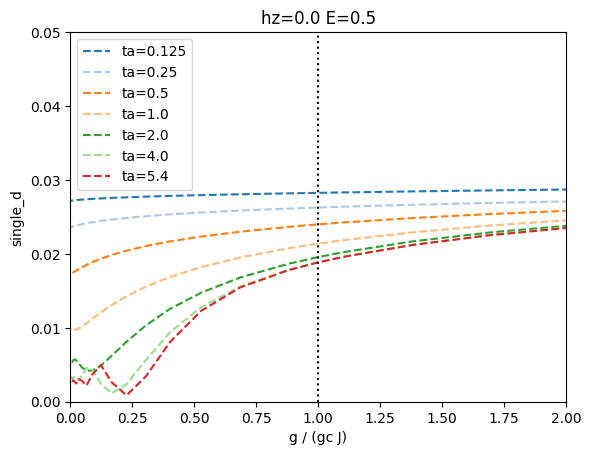

In [26]:
ax = plt.gca()
hz = 0.0
E = 0.5
plot_ax(ax, hz, E, D = 12, val= 'single_d', bb='ZZ', in_g=True)
ax.legend()
ax.set_ylim([0, 0.05])

In [29]:
tas = 2 ** np.linspace(0, 4, 33)
tas

array([ 1.        ,  1.09050773,  1.18920712,  1.29683955,  1.41421356,
        1.54221083,  1.68179283,  1.83400809,  2.        ,  2.18101547,
        2.37841423,  2.59367911,  2.82842712,  3.08442165,  3.36358566,
        3.66801617,  4.        ,  4.36203093,  4.75682846,  5.18735822,
        5.65685425,  6.1688433 ,  6.72717132,  7.33603235,  8.        ,
        8.72406186,  9.51365692, 10.37471644, 11.3137085 , 12.3376866 ,
       13.45434264, 14.67206469, 16.        ])

In [9]:
def plot_ax(ax, hz, E, D = 12, val= ((1, 1), (1, 1)), bb='ZZ', in_g=False):
    Dline = {8: ':', 12:'--', 16: "-.", 20: "-"}
    gc = 3.04438
    colors = sns.color_palette("tab20")
    tas = [0.125, 0.25, 0.5, 1.0, 2.0, 4.0, 5.4,]
    sc = get_sc(E)

    fg, fJ = load_drive(E, smooth=100)

    for ii, ta in enumerate(tas):
        sfs = get_sf(hz, ta, E)
        sfs = [float(sf) for sf in sfs]
        v = [four[(hz, ta, E, sf, D)][val] for sf in sfs if (hz, ta, E, sf, D) in four]
        sss = np.array(sfs[:len(v)])
        if in_g:
            sss = fg(sss) /  (fJ(sss) * gc)

        v = np.abs(v)
        #v = v - fgs[val][hz](sss)
        line, = ax.plot(sss, v, Dline[D], color=colors[ii])
        line.set_label(f"{ta=}")
    #ax.axvline(x=0.4, linestyle=':', color='k')

    ax.set_ylabel(val)
    ax.set_title(f"{hz=} {E=}")
    ax.set_ylim([0, 1.0])
    if in_g:
        ax.set_xlim([0, 2])
        ax.axvline(x=1, linestyle=':', color='k')
        ax.set_xlabel("g / (gc J)")
    else:
        ax.set_xlabel("s")
        ax.axvline(x=sc, linestyle=':', color='k')
        if E < 0:
            ax.set_xlim([0, 1.0])
        else:
            ax.set_xlim([0, 0.6])


/tmp/ipykernel_47673/2685377749.py:15: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  axs[ii, 6].plot(x, fgs[val][hz](x), label=val)


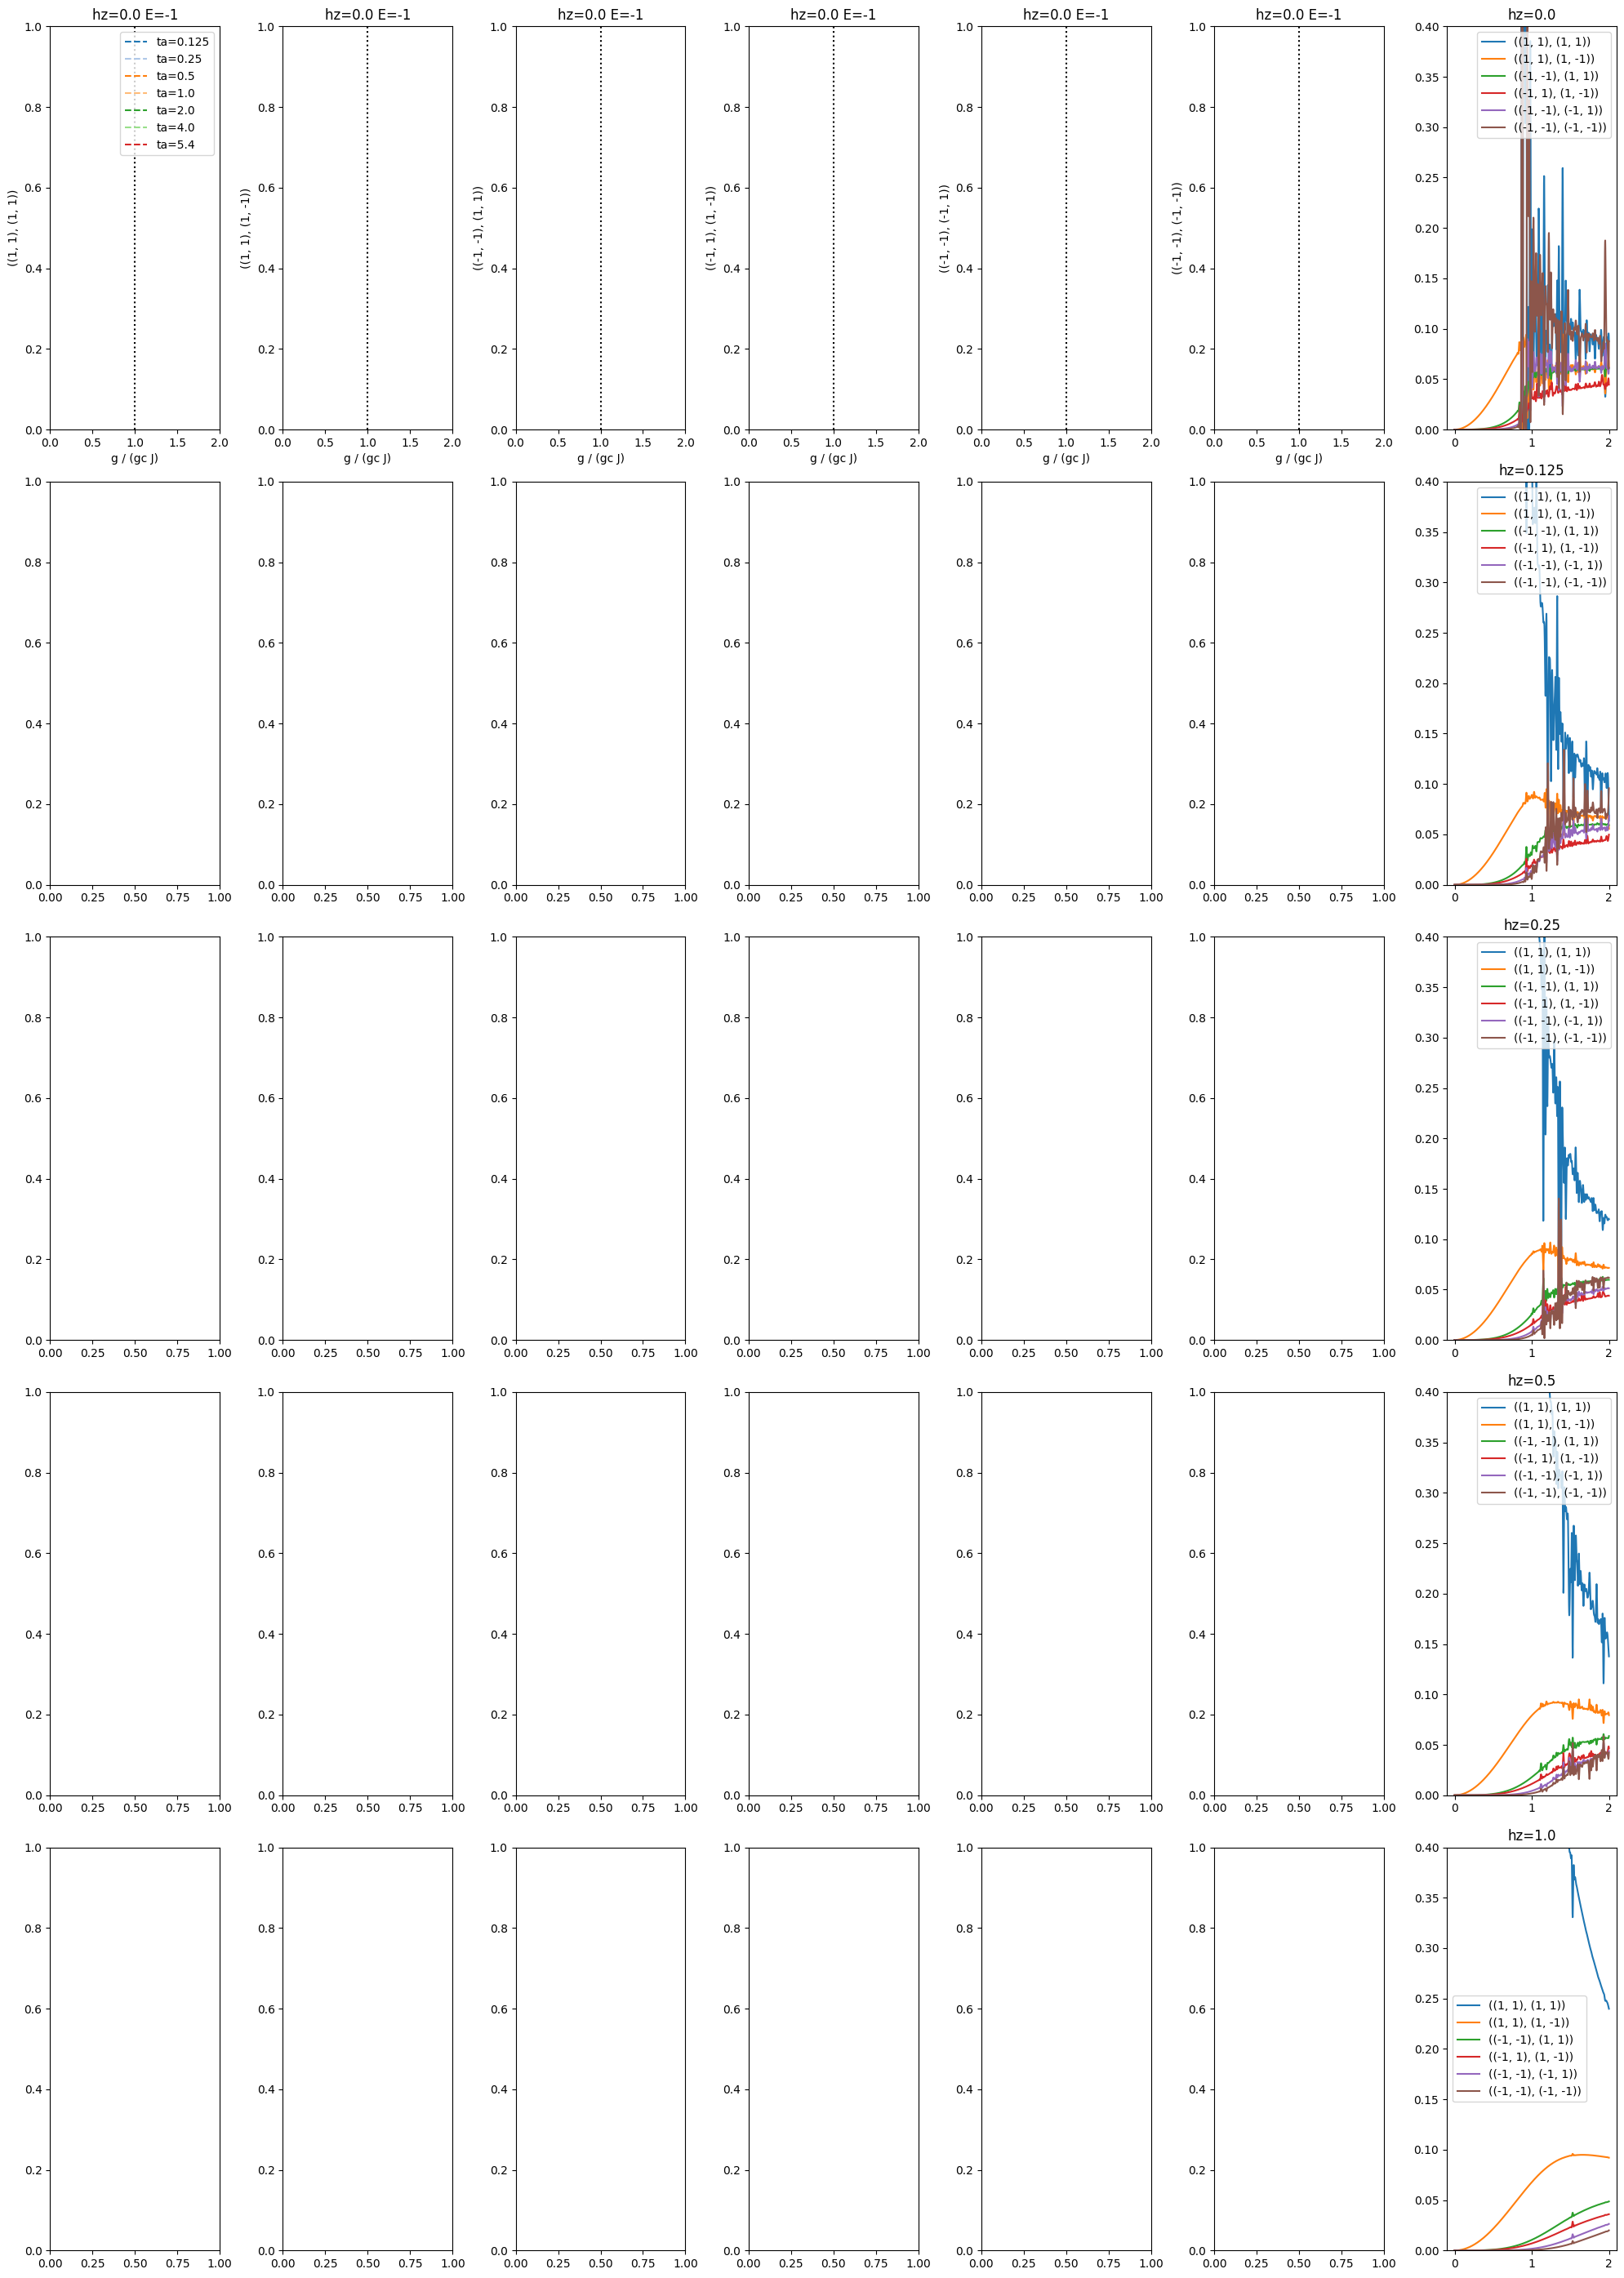

In [12]:
fig, axs = plt.subplots(5, 7)
fig.set_size_inches(20, 28)

for ii, hz in enumerate([0.0] ): #, 0.125, 0.25, 0.5, 1.0]):
    for jj, val in enumerate([((1, 1), (1, 1)), ((1, 1), (1, -1)), ((-1, -1), (1, 1)), ((-1, 1), (1, -1)), ((-1, -1), (-1, 1)), ((-1, -1), (-1, -1))]):
        plot_ax(axs[ii, jj], hz, E=-1, val=val, D=12, in_g=True)
axs[0, 0].legend()



for ii, hz in enumerate([0.0, 0.125, 0.25, 0.5, 1.0]):

    x = np.linspace(0, 2, 1001)
    for val in [((1, 1), (1, 1)), ((1, 1), (1, -1)), ((-1, -1), (1, 1)), ((-1, 1), (1, -1)), ((-1, -1), (-1, 1)), ((-1, -1), (-1, -1))]:
        axs[ii, 6].plot(x, fgs[val][hz](x), label=val)
        axs[ii, 6].set_title(f"{hz=}")
        axs[ii, 6].set_ylim([0, 0.4])
        axs[ii, 6].legend()
fig.tight_layout()

/tmp/ipykernel_47673/4279604522.py:8: MatplotlibDeprecationWarning: Passing label as a length 2 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  axs[ii].plot(x, fgs[val][hz](x), label=val)


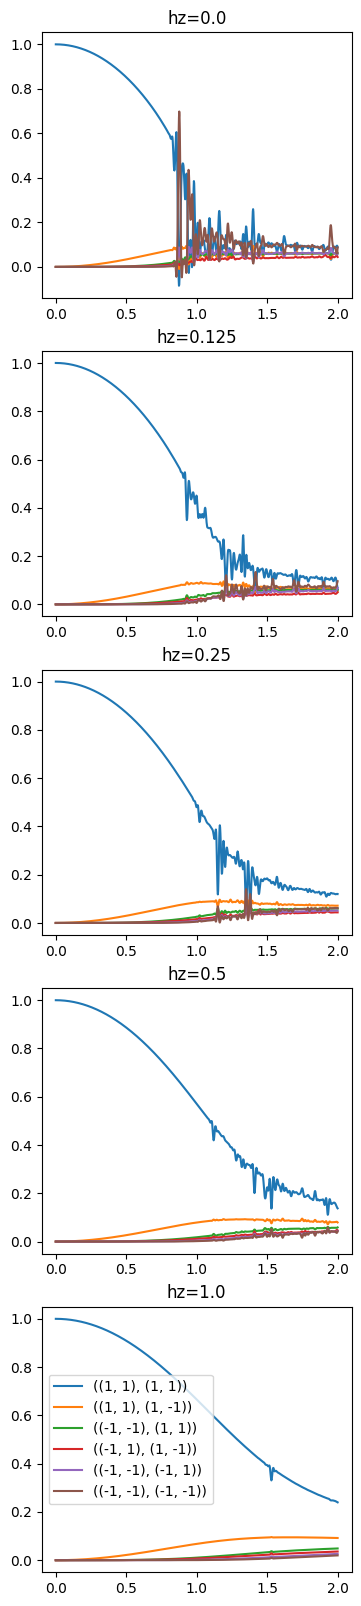

In [11]:
fig, axs = plt.subplots(5, 1)
fig.set_size_inches(4, 20)

for ii, hz in enumerate([0.0, 0.125, 0.25, 0.5, 1.0]):

    x = np.linspace(0, 2, 1001)
    for val in [((1, 1), (1, 1)), ((1, 1), (1, -1)), ((-1, -1), (1, 1)), ((-1, 1), (1, -1)), ((-1, -1), (-1, 1)), ((-1, -1), (-1, -1))]:
        axs[ii].plot(x, fgs[val][hz](x), label=val)
        axs[ii].set_title(f"{hz=}")

plt.legend()